# Regresión lineal

Este ejercicio utiliza el conjunto de datos de diabetes, un conjunto de características que pueden usarse para predecir la evolución de la diabetes.  
Usaremos un modelo de regresión lineal.

## Características del conjunto de datos

* Número de instancias: 442  
* Número de atributos: Las primeras 10 columnas son valores predictivos numéricos  
* Información de las características:

        age: edad en años  
        sex: sexo  
        bmi: índice de masa corporal  
        bp: presión arterial promedio  
        s1: tc, colesterol total en suero  
        s2: ldl, lipoproteínas de baja densidad  
        s3: hdl, lipoproteínas de alta densidad  
        s4: tch, colesterol total / HDL  
        s5: ltg, posiblemente el logaritmo del nivel de triglicéridos en suero  
        s6: glu, nivel de azúcar en sangre  

    **Nota**: Cada una de estas 10 variables de características ha sido centrada en su media y escalada por la desviación estándar multiplicada por la raíz cuadrada del número de muestras (es decir, la suma de cuadrados de cada columna totaliza 1).

* Variable objetivo: La columna 11 es una medida cuantitativa del progreso de la enfermedad un año después del punto de partida (baseline)

## Fuente del conjunto de datos  
https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html  

## Pasos guiados  
### 1. Cargar el conjunto de datos

Carga el conjunto de datos como dataframes de pandas.


In [ ]:
from sklearn import datasets
diabetes= datasets.load_diabetes(as_frame=True)
diabete_df=diabetes.frame
diabete_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Dividir en conjuntos de entrenamiento y prueba

Por ahora, usemos solo una característica: **bmi**. Crea un nuevo dataframe que contenga únicamente esta característica, y divídelo en un conjunto de entrenamiento (80%) y uno de prueba (20%).

**Nota**: para dividir los datos, puedes usar la función `train_test_split` del módulo `sklearn.model_selection`.  
¿Qué ventaja tiene esta función sobre simplemente hacer *slicing* del dataframe?


In [2]:
# Code here
from sklearn.model_selection import train_test_split
bmi_df= diabete_df[['bmi','target']]
train_set,test_set= train_test_split(bmi_df,train_size=0.8,random_state=20)
train_set.shape,test_set.shape

((353, 2), (89, 2))

### Cargar y entrenar el modelo

Carga el modelo de regresión lineal desde `sklearn.linear_model` y entrénalo con los datos de entrenamiento.

In [3]:
# Code here
from sklearn.linear_model import LinearRegression
ls=LinearRegression()
ls.fit(train_set[['bmi']],train_set[['target']])

LinearRegression()

### Evaluar el modelo

Evalúa el modelo utilizando los datos de prueba. Puedes usar las funciones `mean_squared_error` y `r2_score` (el coeficiente de determinación) del módulo `sklearn.metrics`.

In [4]:
# Code here
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_pred=ls.predict(test_set[['bmi']])
mse=mean_squared_error(test_set[['target']],y_pred)
r2=r2_score(test_set[['target']],y_pred)
r2

0.21847731902398215

### Graficar los resultados con matplotlib

Grafica los datos de prueba como un diagrama de dispersión (*scatter plot*), y las predicciones como una línea.

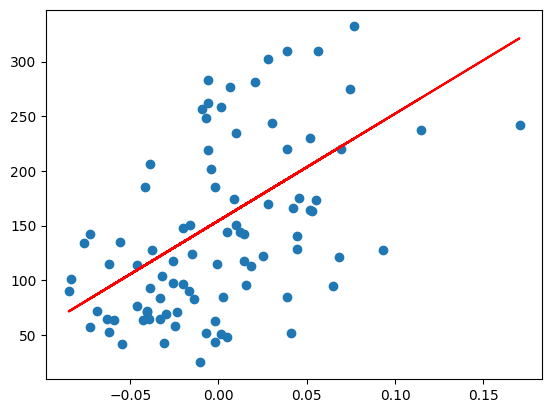

In [5]:
from matplotlib import pyplot as plt
plt.scatter(test_set[['bmi']],test_set[['target']])
plt.plot(test_set[['bmi']],y_pred,color='red')

### 2. Regresión lineal multivariada

Revisa los valores del paso anterior de evaluación del modelo. ¿Es bueno el modelo? ¿Qué significan estas métricas? ¿Cambian mucho los resultados del modelo si ejecutás el código nuevamente? (Recordá que los conjuntos de entrenamiento y prueba se seleccionan aleatoriamente, por lo que tiene sentido que los resultados varíen un poco).

En esta sección usaremos **todas las características** del conjunto de datos:

- Divide los datos (todas las características) en conjuntos de entrenamiento (80%) y prueba (20%) nuevamente  
- Entrena el modelo con los datos de entrenamiento  
- Evalúa el modelo con los datos de prueba

¿Qué observás? ¿El rendimiento del modelo es mejor? ¿Creés que todas las características son útiles para la predicción? ¿Por qué?

In [6]:
# Code here
train_set,test_set= train_test_split(diabete_df,train_size=0.8,random_state=20)
train_set.shape,test_set.shape
ls=LinearRegression()
ls.fit(train_set.iloc[:,:-1],train_set[['target']])
y_pred=ls.predict(test_set.iloc[:,:-1])
mse=mean_squared_error(test_set[['target']],y_pred)
r2=r2_score(test_set[['target']],y_pred)
print(mse,r2)

3461.662786255047 0.41797754631986483
